# Import libraries

In [2]:
# install mplfinance
!pip install mplfinance
!pip install seaborn

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf

# Check files on disk
* Go to the classroom and download the financial_data file
* Extract the data in your folder, or updload it on Google Colab.
    * You can directly upload a 'zip' file on Google Drive.
    * Then, you'll have to mount google drive, find the correct folder and unzip the file
    * You can achieve this by  adapting the following code

In [4]:
import os
dirpath='./Financial Data/stocks'
for dirname, _, filenames in os.walk(dirpath): # for each directory in current folder (./)+path
    for filename in filenames: # for each file in a directory
        print(os.path.join(dirname, filename)) # print the directory/filename

./Financial Data/stocks/CSCO.csv
./Financial Data/stocks/GILD.csv
./Financial Data/stocks/ADBE.csv
./Financial Data/stocks/PEP.csv
./Financial Data/stocks/SBUX.csv
./Financial Data/stocks/AMZN.csv
./Financial Data/stocks/INTC.csv
./Financial Data/stocks/PYPL.csv
./Financial Data/stocks/MSFT.csv
./Financial Data/stocks/AMD.csv
./Financial Data/stocks/NVDA.csv
./Financial Data/stocks/CMCSA.csv
./Financial Data/stocks/NFLX.csv
./Financial Data/stocks/TSLA.csv
./Financial Data/stocks/GOOGL.csv
./Financial Data/stocks/META.csv
./Financial Data/stocks/GOOG.csv
./Financial Data/stocks/AMGN.csv
./Financial Data/stocks/QCOM.csv
./Financial Data/stocks/AAPL.csv


# Open a file as a pandas dataframe

Pandas is very well documented, check here for a complete User Guide :

https://pandas.pydata.org/docs/user_guide/index.html

* Choose one stock file and open it as a DataFrame using the method pd.read_csv(filepath)

In [5]:
Tesla_Stocks = os.path.join(dirpath, "TSLA.csv")
Tesla_df = pd.read_csv(Tesla_Stocks)

print(Tesla_df)

            Date        Open        High         Low       Close     Volume  \
0     2010-06-29    1.266667    1.666667    1.169333    1.592667  281494500   
1     2010-06-30    1.719333    2.028000    1.553333    1.588667  257806500   
2     2010-07-01    1.666667    1.728000    1.351333    1.464000  123282000   
3     2010-07-02    1.533333    1.540000    1.247333    1.280000   77097000   
4     2010-07-06    1.333333    1.333333    1.055333    1.074000  103003500   
...          ...         ...         ...         ...         ...        ...   
3255  2023-06-05  217.800003  221.289993  214.520004  217.610001  151143100   
3256  2023-06-06  216.139999  221.910004  212.529999  221.309998  146911600   
3257  2023-06-07  228.000000  230.830002  223.199997  224.570007  185710800   
3258  2023-06-08  224.220001  235.229996  223.009995  234.860001  164489700   
3259  2023-06-09  249.070007  252.419998  242.020004  244.399994  199882300   

     Symbol   YTD Gains  
0      TSLA    0.000000  

# Set up the Dataframe

* convert values in the 'Date' column using pd.to_datetime(dfcolumn)
* set the date as index using df.set_index(column, inplace = True)
* check the first few lines of the dataframe using head()
* what happens if you type 'print(df[(df.index.day==1) & (df.index.month==9)]). Why ?

In [6]:
#Converting the date to pandas datetime

Tesla_df['Date'] = pd.to_datetime(Tesla_df['Date'])


In [7]:
#Set the date as index

Tesla_df.set_index('Date', inplace=True)


In [8]:
Tesla_df.head()

print(Tesla_df[(Tesla_df.index.day==1) & (Tesla_df.index.month==9)])

                  Open        High         Low       Close     Volume Symbol  \
Date                                                                           
2010-09-01    1.308000    1.379333    1.306667    1.363333    7423500   TSLA   
2011-09-01    1.644000    1.658000    1.589333    1.600000   12721500   TSLA   
2015-09-01   16.022667   16.400000   15.798000   15.908667   81822000   TSLA   
2016-09-01   13.934000   14.073333   13.366667   13.384667  119146500   TSLA   
2017-09-01   23.741333   23.839333   23.579332   23.693333   45742500   TSLA   
2020-09-01  167.380005  167.496674  156.836670  158.350006  269523300   TSLA   
2021-09-01  244.693329  247.330002  243.756668  244.696671   39612900   TSLA   
2022-09-01  272.579987  277.579987  266.149994  277.160004   54287000   TSLA   

             YTD Gains  
Date                    
2010-09-01   -0.143994  
2011-09-01    0.004604  
2015-09-01    8.988696  
2016-09-01    7.403933  
2017-09-01   13.876514  
2020-09-01   98.424429  

# Plot the closing price
You will start using PyPlot here, the most wellknown plotting library for Python.

Have a look here for a few examples :

https://matplotlib.org/stable/tutorials/pyplot.html

* Use df.plot(y = ..., use_index = True) to visualize the closing price
* Use 'plt' and 'sns' functions to improve your figure
    * Define a size for the figure with plt.figure(figsize = (w,h)), unit is inches (typically (12,8))
    * Use df.plot(y = ..., use_index = True) to visualize the closing price
    * set a title with plt.title
    * set labels with plt.xlabel and plt.ylabel
    * set a sns style with sns.set_style(...), options are 'white', 'whitegrid', 'dark', 'darkgrid'
    * show the plot with plt.show()

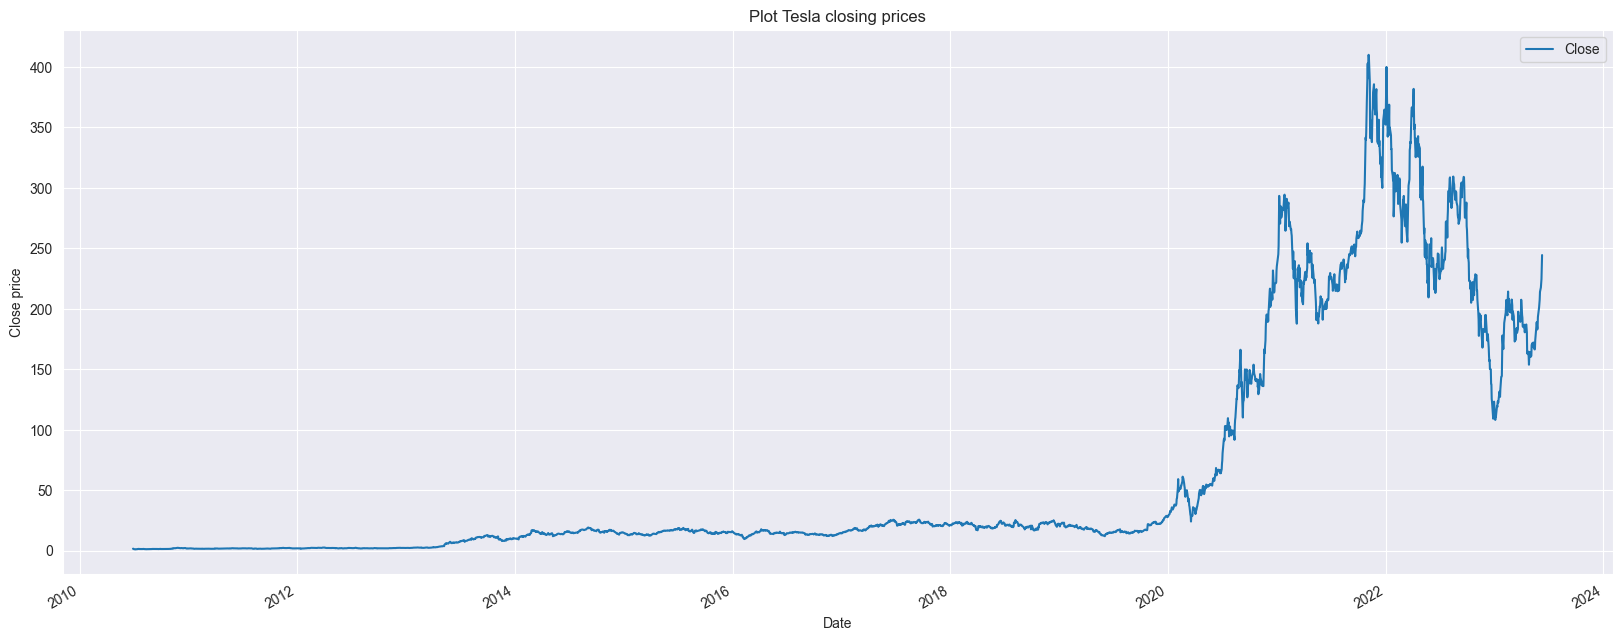

In [12]:
#plt.figure()

Tesla_df.plot(y = 'Close', use_index=True, figsize=(20,8))

plt.title("Plot Tesla closing prices")

plt.xlabel("Date")
plt.ylabel("Close price")
sns.set_style("darkgrid")

plt.show()

# Daily returns
* Let's add a column to our dataset with daily returns
    * For that, you can apply the function pct_change() to the 'Close' column
    * Check the result using df.head()

In [13]:
Tesla_df["Daily"] = Tesla_df["Close"].pct_change()

Tesla_df.head()

,Open,High,Low,Close,Volume,Symbol,YTD Gains,Daily
Date,,,,,,,,
2010-06-29,1.266667,1.666667,1.169333,1.592667,281494500,TSLA,0.000000,NaN
2010-06-30,1.719333,2.028000,1.553333,1.588667,257806500,TSLA,-0.002511,-0.002511
2010-07-01,1.666667,1.728000,1.351333,1.464000,123282000,TSLA,-0.080787,-0.078473
2010-07-02,1.533333,1.540000,1.247333,1.280000,77097000,TSLA,-0.196317,-0.125683
2010-07-06,1.333333,1.333333,1.055333,1.074000,103003500,TSLA,-0.325659,-0.160937


# Plotting daily returns

You will use Seaborn for that plot. Seaborn is a high-level and quite intuitive library.

Check the following link for several plot examples :

https://seaborn.pydata.org/tutorial/introduction.html

* Plot the histogram of daily returns in order to check the distribution
    * This can be done using sns.histplot(..., bins=..., kde=[True/False]). You can vary the bins number and try with or without kde.
    * Don't forget that the first value is a NaN (not a number), you can discard it using df['Your_column'].dropna()
    * You can remove axis if it looks more beautiful to you using sns.despine(left = True). This will remove the top, right (default) and left axis.

<Axes: xlabel='Daily', ylabel='Count'>

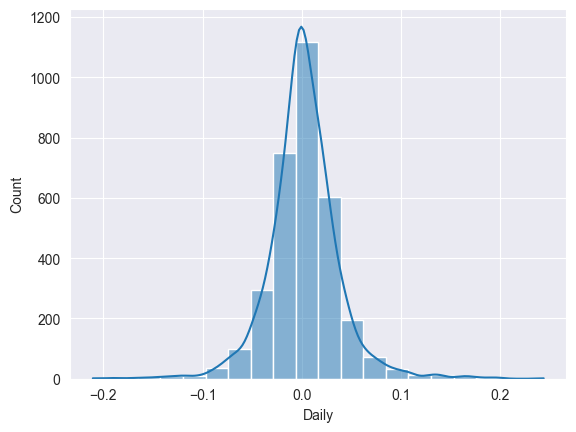

In [17]:
sns.histplot(Tesla_df["Daily"].dropna(), bins=20, kde=True)



# Candlestick charts
Matplotlib also contains a library specialized for Finance, called mplfinance

Have a look here for a list of tutorials :

https://github.com/matplotlib/mplfinance#tutorials

* A bit of preprocessing is needed on the dataframe
    * First, filter the dataframe to only keep data from 2022 or after. In other words, you want all the rows for which df.index.year>2021. Store that in a new dataframe.
    * Then, compute a monthly mean by applying the functions resample(...) and mean() to your new dataframe. Again, store that in a new dataframe.
* Visualize the candlestick plot with mplfinance
    * Import the correct library (mplfinance, usually loaded as mpf)
    * Plot using mpf.plot(..., type = 'candle', style = '...', volume = [True|False])
    * Try different styles, different options and see the impact on the figure

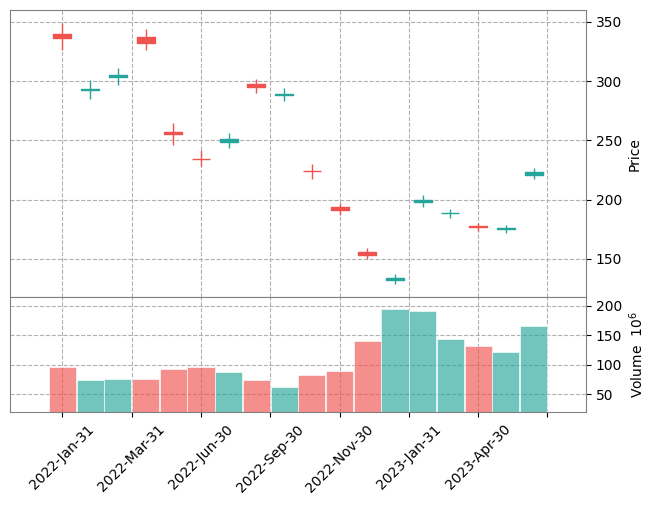

In [58]:
new_df = Tesla_df[Tesla_df.index.year>2021]

mean_df = new_df.resample('ME').mean(numeric_only = True)

#mpf.available_styles()

mpf.plot(mean_df,type='candle', style = 'tradingview', volume=True)